# WordPress.org Data Analysis with DuckDB

This notebook demonstrates how to query WordPress.org data that has been extracted using Meltano and loaded into DuckDB.

In [1]:
import duckdb
import html

try:
    import pandas as pd
    import matplotlib.pyplot as plt
    VISUALIZATION_AVAILABLE = True
except ImportError as e:
    print(f"Visualization libraries not available: {e}")
    print("Run: pip install pandas matplotlib")
    VISUALIZATION_AVAILABLE = False

def clean_name(name):
    return html.unescape(name) if name else name

conn = duckdb.connect('../data/wordpress_data.duckdb')
print("Connected to WordPress.org database!")

Connected to WordPress.org database!


## Quick Start - Your First Query

This query shows the most popular WordPress plugins. Try modifying `LIMIT 10` to see more results, or change `ORDER BY active_installs DESC` to `ORDER BY rating DESC`.

In [2]:
result = conn.execute("""
    SELECT DISTINCT 
        name, 
        active_installs, 
        rating,
        num_ratings,
        short_description
    FROM plugins 
    WHERE active_installs IS NOT NULL 
    ORDER BY active_installs DESC 
    LIMIT 10
""").fetchdf()

result['name'] = result['name'].apply(clean_name)
display(result)

,name,active_installs,rating,num_ratings,short_description
0,Elementor Website Builder – More Than Just a P...,10000000.0,90.0,7185.0,The Elementor Website Builder has it all: drag...
1,Contact Form 7,10000000.0,80.0,2152.0,Just another contact form plugin. Simple but f...
2,Yoast SEO – Advanced SEO with real-time guidan...,10000000.0,96.0,27790.0,"Improve your SEO with real-time feedback, sche..."
3,Classic Editor,9000000.0,98.0,1221.0,Enables the previous &quot;classic&quot; edito...
4,LiteSpeed Cache,7000000.0,96.0,2710.0,All-in-one unbeatable acceleration & PageSpeed...
5,WooCommerce,7000000.0,90.0,4723.0,Everything you need to launch an online store ...
6,Akismet Anti-spam: Spam Protection,6000000.0,94.0,1166.0,The best anti-spam protection to block spam co...
7,WPForms – Easy Form Builder for WordPress – Co...,6000000.0,96.0,14268.0,The best WordPress contact form plugin. Drag &...
8,All-in-One WP Migration and Backup,5000000.0,90.0,7612.0,Trusted by 60M+ sites: The gold standard for W...
9,"Wordfence Security – Firewall, Malware Scan, a...",5000000.0,94.0,4797.0,"Firewall, Malware Scanner, Two Factor Auth, an..."


## Explore Available Tables

In [3]:
tables = conn.execute("SHOW TABLES").fetchall()
for table_name, in tables:
    count = conn.execute(f"SELECT COUNT(*) FROM {table_name}").fetchone()[0]
    schema = conn.execute(f"DESCRIBE {table_name}").fetchall()
    cols = [col_name for col_name, *_ in schema]
    print(f"{table_name}: {count:,} rows, {len(cols)} columns")
    print(f"  Columns: {', '.join(cols[:8])}{'...' if len(cols) > 8 else ''}")
    print()

plugins: 61,026 rows, 22 columns
  Columns: active_installs, added, author, author_profile, contributors, donate_link, download_link, downloaded...



## Plugin Distribution by Active Installations

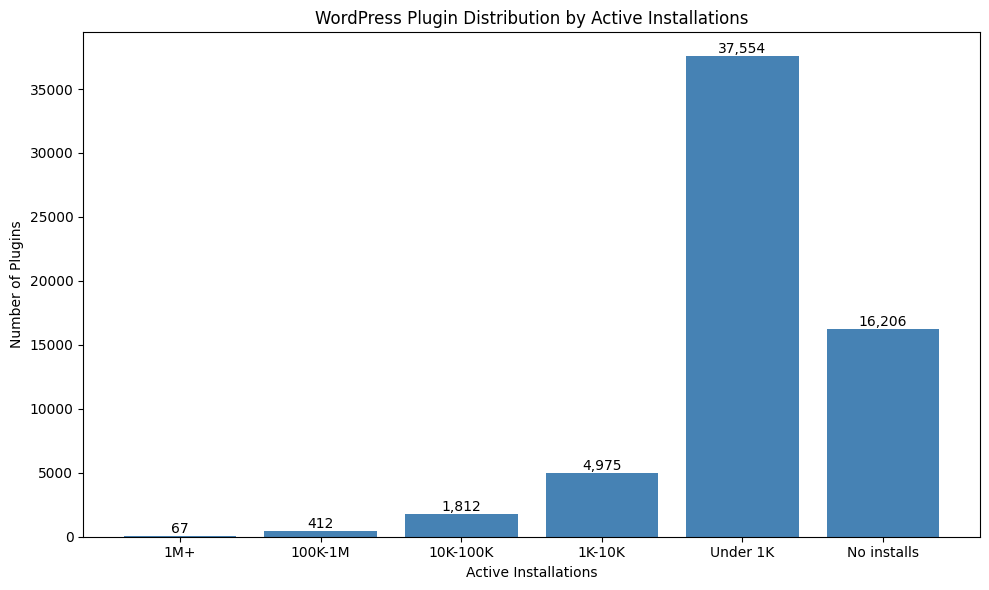

In [4]:
if VISUALIZATION_AVAILABLE:
    install_data = conn.execute("""
        SELECT 
            CASE 
                WHEN active_installs >= 1000000 THEN '1M+'
                WHEN active_installs >= 100000 THEN '100K-1M'
                WHEN active_installs >= 10000 THEN '10K-100K'
                WHEN active_installs >= 1000 THEN '1K-10K'
                WHEN active_installs > 0 THEN 'Under 1K'
                ELSE 'No installs'
            END as install_range,
            COUNT(*) as plugin_count
        FROM plugins 
        WHERE active_installs IS NOT NULL
        GROUP BY install_range
        ORDER BY 
            CASE install_range
                WHEN '1M+' THEN 1
                WHEN '100K-1M' THEN 2
                WHEN '10K-100K' THEN 3
                WHEN '1K-10K' THEN 4
                WHEN 'Under 1K' THEN 5
                ELSE 6
            END
    """).fetchdf()

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(install_data['install_range'], install_data['plugin_count'], color='steelblue')
    ax.set_title('WordPress Plugin Distribution by Active Installations')
    ax.set_xlabel('Active Installations')
    ax.set_ylabel('Number of Plugins')
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    plt.show()

## Upcoming WordPress Events in India

In [5]:
try:
    events = conn.execute("""
        SELECT 
            title,
            type,
            date,
            location->>'location' as city
        FROM events
        ORDER BY date
    """).fetchdf()
    if not events.empty:
        display(events)
    else:
        print("No events data. Run 'make extract-events' to load it.")
except Exception as e:
    print(f"Events table not available: {e}")
    print("Run 'make extract-events' to load events data.")

Events table not available: Catalog Error: Table with name events does not exist!
Did you mean "pg_views"?

LINE 7:         FROM events
                     ^
Run 'make extract-events' to load events data.


In [6]:
conn.close()
print("Database connection closed.")

Database connection closed.


## Next Steps

From the terminal:
```bash
make extract-all       # Extract all data streams
make extract-plugins   # Extract plugins only
make extract-events    # Extract events only
make extract-themes    # Extract themes only
make check-data        # Check what data you have
make help              # See all available commands
```

Reconnect anytime:
```python
conn = duckdb.connect('../data/wordpress_data.duckdb')
```